# Fleet Replacement – Linopy Model Usage Demo

This notebook shows how to use the `linopy_model` module to:

1. Construct model inputs (`ModelParams`, `InfoState`, `InitialVehicle`)
2. Assemble `FleetReplacementData`
3. Build price and productivity forecasts with `make_forecast()`
4. Build the optimisation model with `build_model()`
5. Solve with `solve()` and inspect the optimal plan
6. Extract first-period decisions with `best_immediate_actions()`


In [1]:
# import sys

# sys.path.insert(0, "../src")
# sys.path.insert(0, ".")  # for plot_helpers

import numpy as np

from fleet_replacement.policies.linopy_model import (
    VehicleType,
    FleetReplacementData,
    ForecastParams,
    InfoState,
    InitialVehicle,
    ModelParams,
    best_immediate_actions,
    build_model,
    make_forecast,
    solve,
)
from plot_helpers import plot_decisions, plot_fleet_composition, plot_forecasts

## 1. Model parameters

`ModelParams` holds deterministic planning parameters: operational constants, the BET productivity cap, financial parameters, and the discount factor. Price growth rates have been moved to `ForecastParams` (see step 4). In production these are built from an `EnvConfig` via `ModelParams.from_env_config(config, horizon)`.


In [2]:
params = ModelParams(
    horizon=10,
    max_age=7,
    # Operational
    income_per_km=30.0,  # SEK/km
    annual_mileage_km=130_000,
    fuel_consumption_l_per_km=0.6,
    el_consumption_kWh_per_km=2.5,
    driver_salary_annual=450_000,  # SEK
    # Productivity cap
    BET_productivity_max=1.0,
    # Financial
    interest_rate=0.05,
    loan_fraction=0.7,
    economic_lifetime=10,
    # Discount factor
    gamma=0.95,
)
params

ModelParams(horizon=10, max_age=7, income_per_km=30.0, annual_mileage_km=130000, fuel_consumption_l_per_km=0.6, el_consumption_kWh_per_km=2.5, driver_salary_annual=450000, BET_productivity_max=1.0, interest_rate=0.05, loan_fraction=0.7, economic_lifetime=10, gamma=0.95)

## 2. Information state

`InfoState` represents the current market observation: energy prices, vehicle purchase prices, and the current BET productivity level. In a simulation loop this is populated from the environment observation at each step.


In [3]:
info_state = InfoState(
    year=2025,
    energy_price_diesel=18.0,  # SEK/litre
    energy_price_electricity=3.0,  # SEK/kWh
    purchase_price_DT=1_500_000.0,  # SEK
    purchase_price_BET=2_000_000.0,  # SEK
    productivity_BET=0.85,  # fraction of DT productivity
)
info_state

InfoState(year=2025, energy_price_diesel=18.0, energy_price_electricity=3.0, purchase_price_DT=1500000.0, purchase_price_BET=2000000.0, productivity_BET=0.85)

## 3. Initial fleet

Each `InitialVehicle` records the type, age, and historical purchase price of the vehicle currently occupying that slot. Slot order (0-based) is preserved throughout the model.


In [4]:
initial_fleet = [
    InitialVehicle(VehicleType.DT, age=0, purchase_price=1_500_000.0),
    InitialVehicle(VehicleType.DT, age=2, purchase_price=1_480_000.0),
    InitialVehicle(VehicleType.DT, age=3, purchase_price=1_450_000.0),
    InitialVehicle(VehicleType.DT, age=0, purchase_price=1_450_000.0),
    InitialVehicle(VehicleType.DT, age=1, purchase_price=1_490_000.0),
]

for slot, v in enumerate(initial_fleet):
    print(
        f"  slot {slot}: {v.vehicle_type:>3}  age={v.age}  purchase_price={v.purchase_price:,.0f} SEK"
    )

  slot 0:  DT  age=0  purchase_price=1,500,000 SEK
  slot 1:  DT  age=2  purchase_price=1,480,000 SEK
  slot 2:  DT  age=3  purchase_price=1,450,000 SEK
  slot 3:  DT  age=0  purchase_price=1,450,000 SEK
  slot 4:  DT  age=1  purchase_price=1,490,000 SEK


## 4. Forecast

`make_forecast` projects each price series and BET productivity linearly from the current `InfoState` for the full planning horizon. Pass a `ForecastParams` to set per-series growth rates; all default to 0 (flat forecast).


In [5]:
fp = ForecastParams(
    diesel_price_growth=0.01,  # +1 % per year
    electricity_price_growth=0.00,  # flat
    purchase_price_growth_DT=0.00,  # flat
    purchase_price_growth_BET=-0.05,  # -5 % per year (cost reduction)
    BET_productivity_growth=0.00,  # flat
)

forecast = make_forecast(
    info_state,
    horizon=params.horizon,
    BET_productivity_max=params.BET_productivity_max,
    forecast_params=fp,
)
forecast

Forecast(purchase_price_DT=array([1500000., 1500000., 1500000., 1500000., 1500000., 1500000.,
       1500000., 1500000., 1500000., 1500000.]), purchase_price_BET=array([2000000., 1900000., 1800000., 1700000., 1600000., 1500000.,
       1400000., 1300000., 1200000., 1100000.]), energy_price_diesel=array([18.  , 18.18, 18.36, 18.54, 18.72, 18.9 , 19.08, 19.26, 19.44,
       19.62]), energy_price_electricity=array([3., 3., 3., 3., 3., 3., 3., 3., 3., 3.]), productivity_BET=array([0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.85]))

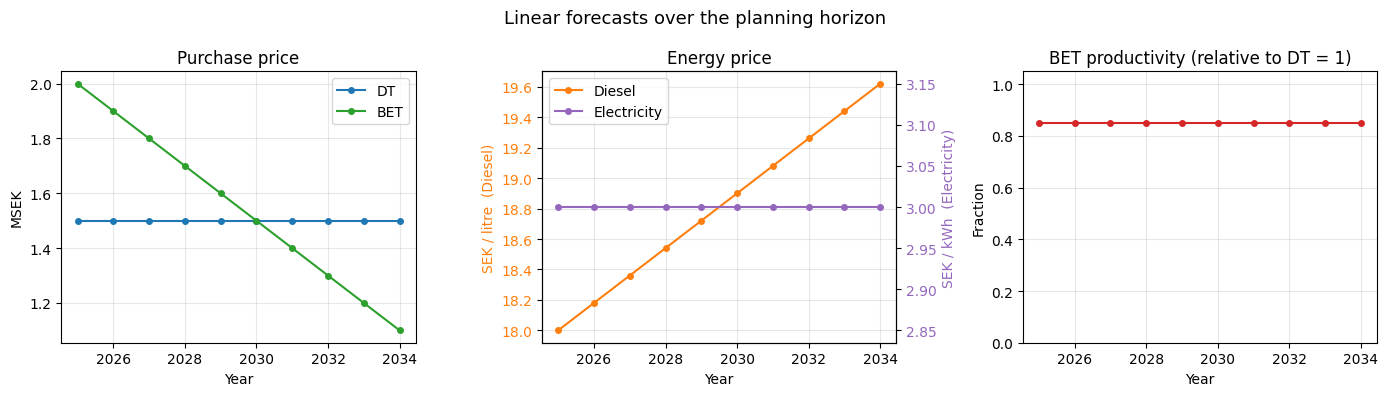

In [6]:
plot_forecasts(forecast, info_state, params)

## 5. Assemble and solve

`FleetReplacementData` packages all inputs. `build_model` constructs the linopy model using the forecast, and `solve` calls HiGHS to find the optimum.


In [7]:
data = FleetReplacementData(
    params=params,
    info_state=info_state,
    initial_fleet=initial_fleet,
)

model = build_model(data, forecast)
model = solve(model)
print("Objective value:", model.objective.value)

Objective value: 97612935.05199057


## 6. Optimal plan

The full solution is available in `model.solution`. Below we collapse the vehicle-state dimensions to recover the active decision for each `(time, slot)` pair.


In [8]:
x_sol = model.solution["x"]

active_decisions = (
    x_sol.fillna(0)
    .sum(["vehicle_type", "vehicle_age"])  # → (time, slot, decision)
    .to_series()
    .rename("active")
    .reset_index()
    .query("active > 0.5")[["time", "slot", "decision"]]
    .reset_index(drop=True)
)
active_decisions

c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


,time,slot,decision
0,0,0,Replace_DT
1,0,1,Keep
2,0,2,Keep
3,0,3,Keep
4,0,4,Keep
5,1,0,Replace_BET
6,1,1,Replace_BET
7,1,2,Replace_BET
8,1,3,Replace_BET
9,1,4,Replace_BET


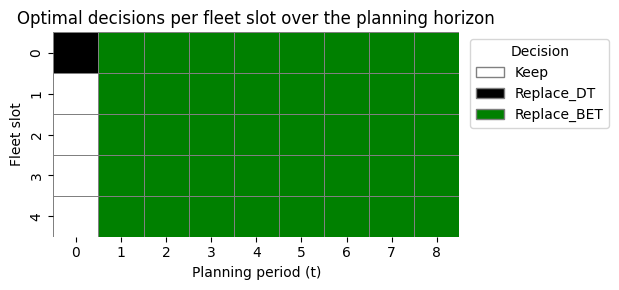

In [9]:
plot_decisions(active_decisions)

c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


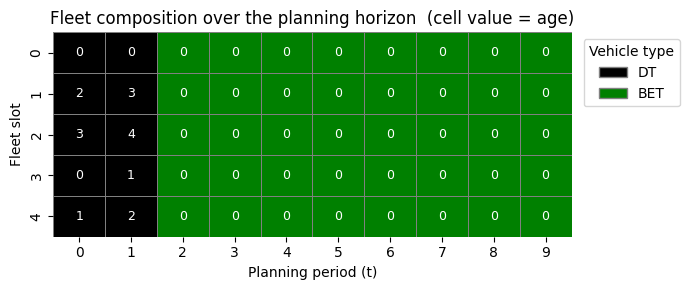

In [10]:
plot_fleet_composition(model)

## 7. First-period decisions (simulation interface)

`best_immediate_actions()` returns only the `t=0` decisions — the values that are fed back into the stochastic simulation at each step.


In [11]:
actions = best_immediate_actions(model, data)

for slot, (vehicle, action) in enumerate(zip(initial_fleet, actions)):
    print(f"  slot {slot}: {vehicle.vehicle_type} age={vehicle.age}  → {action}")

  slot 0: DT age=0  → Replace_DT
  slot 1: DT age=2  → Keep
  slot 2: DT age=3  → Keep
  slot 3: DT age=0  → Keep
  slot 4: DT age=1  → Keep


c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
